In [ ]:
"""
Task: 4
Make a graph of rught! You will need to make use of 2 conditional edges!
"""

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class AgentState(TypedDict):
    """
    This is the state for my agent
    """

    number_one: int
    number_two: int
    number_three: int
    number_four: int
    result_one: int
    result_two: int
    operation_one: str
    operation_two: str

In [2]:
def addition_node_one(state: AgentState) -> AgentState:
    """
    This node perform addition of first two numbers 
    """

    state['result_one'] =  state['number_one'] + state['number_two']
    return state

def subtarction_node_one(state: AgentState) -> AgentState:
    """
    This node performs subtraction for first two numbers
    """

    state['result_one'] = state['number_one'] - state['number_two']
    return state

def selection_node_one(state: AgentState) -> AgentState:
    """ 
    This is the first selection node that will decide the operation for first two numbers
    """

    if state['operation_one'] == '+':
        return "addition_node_one"
    else:
        return "subtraction_node_one" 


def addition_node_two(state: AgentState) -> AgentState:
    """
    This node will add the last two numbers in the state
    """

    state['result_two'] =  state['number_three'] + state['number_four'] 
    return state

def subtraction_node_two(state: AgentState) -> AgentState:
    """
    This node will subtract the last two number from the state
    """

    state['result_two'] = state['number_three'] - state['number_four']
    return state

def selection_node_two(state: AgentState) -> AgentState:
    """ 
    This is the first selection node that will decide the operation for last two numbers
    """

    if state['operation_two'] == '+':
        return "addition_node_two"
    else:
        return "subtraction_node_two" 

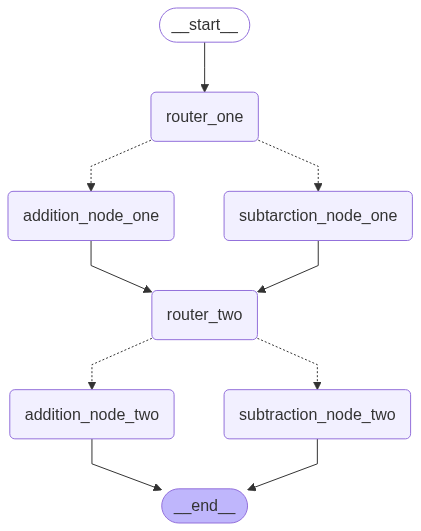

In [8]:
graph = StateGraph(AgentState)

graph.add_node(addition_node_one, "addition_node_one")
graph.add_node(subtarction_node_one, "subtraction_node_one")
graph.add_node(addition_node_two, "addition_node_two")
graph.add_node(subtraction_node_two, "subtraction_node_two")
graph.add_node("router_one", lambda state:state)
graph.add_node("router_two", lambda state:state)
graph.add_edge(START, "router_one")
graph.add_conditional_edges("router_one", selection_node_one,
                            {
                               "addition_node_one": "addition_node_one",
                               "subtarction_node_one": "subtarction_node_one"
                            })
graph.add_conditional_edges("router_two", selection_node_two,
                            {
                                "addition_node_two": "addition_node_two",
                                "subtraction_node_two": "subtraction_node_two"
                            })
graph.add_edge("addition_node_one", "router_two")
graph.add_edge("subtarction_node_one", "router_two")
""" graph.add_edge(END, addition_node_two)
graph.add_edge(END, subtraction_node_two) """

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))


In [9]:
initial_state = AgentState(
    number_one = 5,
    number_two = 8,
    number_three = 9,
    number_four = 6,
    operation_one = "+",
    operation_two = "-"
)

result = app.invoke(initial_state)

print(result)

{'number_one': 5, 'number_two': 8, 'number_three': 9, 'number_four': 6, 'result_one': 13, 'result_two': 3, 'operation_one': '+', 'operation_two': '-'}
